In [ ]:
import shutil

#shutil.rmtree('/content/dataset_stft')
#shutil.rmtree('/content/dataset_wavelet')

In [ ]:
from google.colab import files

shutil.make_archive('/content/dataset_stft', 'zip', '/content/dataset_stft')
files.download('/content/dataset_stft.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import csv
import time
import json
import argparse
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import pywt
import yfinance as yf
from scipy import signal
from PIL import Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.cm as cm

warnings.filterwarnings("ignore")


## Generación de dataset

In [ ]:
#!/usr/bin/env python3
"""
=============================================================================
 GENERADOR DE DATASETS DE ESPECTROGRAMAS FINANCIEROS
 Multi-activo: crypto, commodities, stocks, FX
 Horizontes de etiquetado: 1d, 5d, 10d, 20d, 30d
 Etiquetas: BUY / HOLD / SELL  (umbrales adaptativos por ATR)
 2026 reservado como test set

 Genera DOS datasets con la MISMA estructura y etiquetas:
   dataset_stft/    — imágenes basadas en Short-Time Fourier Transform
   dataset_wavelet/ — imágenes basadas en Continuous Wavelet Transform (Morlet)

 Estructura de cada dataset:
   images/
     train/   BTC-USD_00060.png ...
     test/    ...
   labels.csv
     sample_id, filename, ticker, asset_class, date, split, atr,
     ret_1d,  ret_5d,  ret_10d,  ret_20d,  ret_30d,
     label_1d, label_5d, label_10d, label_20d, label_30d
=============================================================================
"""



# ═════════════════════════════════════════════════════════════════════════════
# UNIVERSO DE ACTIVOS
# ═════════════════════════════════════════════════════════════════════════════

ASSET_UNIVERSE = {
    "crypto": [
        "BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD", "ADA-USD"
        # "BTC-USD",
    ],
    "stocks": [
         "AAPL", "MSFT", "GOOGL", "SPY", "NVDA", "KO", "TSLA", "AMD", "META", "NFLX"
         #"AAPL",
    ],
    "commodities": [
        "GC=F", "SI=F", "CL=F"
    ],
    "fx": [
        "EURUSD=X", #"GBPUSD=X",
    ],
}

# ═════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ═════════════════════════════════════════════════════════════════════════════

HORIZONS    = [3, 7, 15, 30]
WINDOW_DAYS = 90        # días de historia para cada muestra
IMG_SIZE    = 92        # píxeles de salida
CMAP        = "magma"
PAD_LENGTH  = 16        # días de padding por reflexión
START_DATE  = "2021-01-01"
TRAIN_END   = "2025-12-31"
TEST_START  = "2026-01-01"
MIN_HISTORY = 200       # mínimo de días para procesar un activo

# Configuración STFT
STFT_CFG = {
    "stft_window":  32,   # tamaño de ventana Hann
    "stft_overlap": 28,   # solapamiento entre ventanas
    "nfft":         64,   # resolución FFT (zero-padding)
}

# Configuración Wavelet de Morlet continua
# cmor{B}-{C}: B = bandwidth (ancho de banda), C = frecuencia central
# cmor1.5-1.0 es el estándar en análisis financiero
# scales: cada valor s representa un ciclo de aproximadamente s días
WAVELET_CFG = {
    "wavelet": "cmor1.5-1.0",
    "scales":  list(range(2, 31)),  # ciclos de 2 a 30 días
}

ATR_CFG = {
    "period":           14,
    "buy_multiplier":  0.7,
    "sell_multiplier": 0.7,
}


# ═════════════════════════════════════════════════════════════════════════════
# PREPROCESAMIENTO DE SEÑAL
# ═════════════════════════════════════════════════════════════════════════════

def log_returns(close: np.ndarray) -> np.ndarray:
    """r_t = log(P_t / P_{t-1})  —  serie estacionaria y aditiva."""
    return np.diff(np.log(close))


def zscore(x: np.ndarray) -> np.ndarray:
    """Normalización Z. Media 0, std 1. Hace comparables activos distintos."""
    std = x.std()
    return (x - x.mean()) / std if std > 1e-10 else np.zeros_like(x)


def compute_atr(high: np.ndarray, low: np.ndarray,
                close: np.ndarray, period: int = 14) -> np.ndarray:
    """
    ATR como porcentaje del precio (EMA).
    Umbral dinámico: refleja la volatilidad real del activo en ese momento.
    Lo escalamos por sqrt(horizon) al etiquetar porque la volatilidad
    crece con la raíz del tiempo.
    """
    tr = np.maximum(
        high[1:] - low[1:],
        np.maximum(
            np.abs(high[1:] - close[:-1]),
            np.abs(low[1:] - close[:-1]),
        )
    )
    atr_pct = tr / close[:-1]
    atr = np.full_like(atr_pct, np.nan)
    atr[period - 1] = atr_pct[:period].mean()
    alpha = 2.0 / (period + 1)
    for i in range(period, len(atr_pct)):
        atr[i] = alpha * atr_pct[i] + (1 - alpha) * atr[i - 1]
    return atr


def make_label(future_return: float, threshold: float) -> str:
    """
    BUY  →  retorno > +threshold   (señal alcista fuerte)
    SELL →  retorno < -threshold   (señal bajista fuerte)
    HOLD →  cualquier cosa en el medio
    """
    if   future_return >  threshold: return "BUY"
    elif future_return < -threshold: return "SELL"
    else:                            return "HOLD"


# ═════════════════════════════════════════════════════════════════════════════
# GENERACIÓN DE IMÁGENES
# ═════════════════════════════════════════════════════════════════════════════

def make_stft_image(window: np.ndarray) -> np.ndarray:
    """
    STFT: aplica FFT sobre ventanas deslizantes con forma de Hann.
    Resolución tiempo-frecuencia fija para todas las frecuencias.
    Retorna matriz 2D en dB: (n_frecuencias, n_ventanas_temporales)
    """
    padded = np.pad(window, (0, PAD_LENGTH), mode="reflect")
    _, _, Sxx = signal.spectrogram(
        padded,
        fs=1.0,
        window=signal.windows.hann(STFT_CFG["stft_window"]),
        noverlap=STFT_CFG["stft_overlap"],
        nfft=STFT_CFG["nfft"],
        scaling="density",
    )
    # Recortar las columnas del padding
    n_cols_orig = (WINDOW_DAYS - STFT_CFG["stft_window"]) // (
        STFT_CFG["stft_window"] - STFT_CFG["stft_overlap"]
    ) + 1
    return 10 * np.log10(Sxx[:, :n_cols_orig] + 1e-12)


def make_wavelet_image(window: np.ndarray) -> np.ndarray:
    """
    CWT con Wavelet de Morlet compleja (cmor1.5-1.0).
    Resolución adaptativa: ventanas cortas para ciclos cortos,
    ventanas largas para ciclos largos.
    Retorna matriz 2D en dB: (n_scales, n_tiempo)
    Los scales cubren ciclos de 2 a 30 días.
    """
    padded = np.pad(window, (0, PAD_LENGTH), mode="reflect")
    scales = np.array(WAVELET_CFG["scales"], dtype=float)
    coeffs, _ = pywt.cwt(
        padded, scales, WAVELET_CFG["wavelet"], sampling_period=1.0
    )
    power = np.abs(coeffs) ** 2
    # Recortar padding: las primeras WINDOW_DAYS columnas son señal real
    power = power[:, :WINDOW_DAYS]
    return 10 * np.log10(power + 1e-12)


def save_png(matrix: np.ndarray, filepath: str):
    """
    Convierte una matriz 2D a imagen PNG 64×64 usando PIL (sin matplotlib).
    Normaliza a [0,1], aplica colormap magma, flip vertical
    para que frecuencias bajas queden abajo.
    """
    vmin, vmax = matrix.min(), matrix.max()
    norm  = (matrix - vmin) / (vmax - vmin + 1e-10)
    rgba  = cm.get_cmap(CMAP)(norm)
    rgb   = (rgba[:, :, :3] * 255).astype(np.uint8)
    rgb   = rgb[::-1]  # frecuencias bajas abajo
    Image.fromarray(rgb).resize(
        (IMG_SIZE, IMG_SIZE), Image.BILINEAR
    ).save(filepath, format="PNG")


# ═════════════════════════════════════════════════════════════════════════════
# DESCARGA
# ═════════════════════════════════════════════════════════════════════════════

def download(ticker: str, start: str) -> pd.DataFrame | None:
    try:
        df = yf.download(
            ticker, start=start, interval="1d",
            progress=False, auto_adjust=True,
        )
        if df is None or len(df) < MIN_HISTORY:
            print(f"  ⚠  {ticker}: {len(df) if df is not None else 0} registros")
            return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df[["Close", "High", "Low"]].dropna()
    except Exception as e:
        print(f"  ✗  {ticker}: {e}")
        return None


# ═════════════════════════════════════════════════════════════════════════════
# PROCESAMIENTO DE UN ACTIVO
# ═════════════════════════════════════════════════════════════════════════════

def process_asset(ticker: str, asset_class: str, df: pd.DataFrame,
                  img_fn,             # make_stft_image o make_wavelet_image
                  img_dir_train: str,
                  img_dir_test: str) -> list[dict]:
    """
    Genera imágenes y registros de etiquetas para un activo.
    img_fn es la función de transformación: STFT o Wavelet.
    La misma lógica sirve para los dos datasets.
    """
    close  = df["Close"].values.astype(float)
    high   = df["High"].values.astype(float)
    low    = df["Low"].values.astype(float)
    dates  = df.index

    ret      = log_returns(close)
    ret_norm = zscore(ret)
    atr      = compute_atr(high, low, close, ATR_CFG["period"])

    max_horizon = max(HORIZONS)
    records     = []

    for i in range(WINDOW_DAYS, len(ret_norm) - max_horizon):

        # Validar ATR
        atr_val = atr[i] if i < len(atr) and not np.isnan(atr[i]) else None
        if not atr_val or atr_val < 1e-8:
            continue

        sample_date = dates[i + 1]  # +1 por offset de log_returns
        split       = "test" if sample_date >= pd.Timestamp(TEST_START) else "train"
        img_dir     = img_dir_test if split == "test" else img_dir_train
        sample_id   = f"{ticker}_{i:05d}"
        fname       = f"{sample_id}.png"

        # Generar y guardar imagen
        window   = ret_norm[i - WINDOW_DAYS:i]
        matrix   = img_fn(window)
        save_png(matrix, os.path.join(img_dir, fname))

        # Calcular retornos y etiquetas para todos los horizontes
        record = {
            "sample_id":   sample_id,
            "filename":    fname,
            "ticker":      ticker,
            "asset_class": asset_class,
            "date":        str(sample_date.date()),
            "split":       split,
            "atr":         round(float(atr_val), 6),
        }
        for h in HORIZONS:
            future_ret       = float(np.sum(ret[i:i + h]))
            threshold        = atr_val * ATR_CFG["buy_multiplier"] * np.sqrt(h)
            record[f"ret_{h}d"]   = round(future_ret, 6)
            record[f"label_{h}d"] = make_label(future_ret, threshold)

        records.append(record)

        if len(records) % 200 == 0:
            print(f"     ... {len(records)} muestras", end="\r")

    return records


# ═════════════════════════════════════════════════════════════════════════════
# PIPELINE DE GENERACIÓN
# ═════════════════════════════════════════════════════════════════════════════

CSV_FIELDS = (
    ["sample_id", "filename", "ticker", "asset_class", "date", "split", "atr"]
    + [f"ret_{h}d"   for h in HORIZONS]
    + [f"label_{h}d" for h in HORIZONS]
)


def generate(output_dir: str, img_fn, name: str,
             asset_classes: list, start_date: str):
    """
    Genera un dataset completo con la función de imagen indicada.
    name: "STFT" o "Wavelet"  (solo para logging)
    img_fn: make_stft_image o make_wavelet_image
    """
    img_train = os.path.join(output_dir, "images", "train")
    img_test  = os.path.join(output_dir, "images", "test")
    os.makedirs(img_train, exist_ok=True)
    os.makedirs(img_test,  exist_ok=True)

    csv_path = os.path.join(output_dir, "labels.csv")
    if os.path.exists(csv_path):
        os.remove(csv_path)

    print("\n" + "═" * 65)
    print(f" DATASET {name}")
    print(f" Output  : {output_dir}")
    print(f" Ventana : {WINDOW_DAYS} días")
    print(f" Train   : {start_date} → {TRAIN_END}")
    print(f" Test    : {TEST_START} → hoy")
    print("═" * 65)

    total        = 0
    label_counts = {h: {"BUY": 0, "HOLD": 0, "SELL": 0}
                    for h in HORIZONS}

    for asset_class in asset_classes:
        tickers = ASSET_UNIVERSE.get(asset_class, [])
        print(f"\n── {asset_class.upper()} ({len(tickers)} activos) ──")

        for ticker in tickers:
            print(f"  📥 {ticker} ...", end=" ", flush=True)
            df = download(ticker, start_date)
            if df is None:
                continue
            print(f"{len(df)} días  "
                  f"{df.index[0].date()} → {df.index[-1].date()}")

            t0      = time.time()
            records = process_asset(
                ticker, asset_class, df,
                img_fn, img_train, img_test,
            )
            elapsed = time.time() - t0

            if not records:
                print("     ⚠  Sin muestras generadas")
                continue

            # Escribir al CSV de forma incremental
            exists = os.path.exists(csv_path)
            with open(csv_path, "a", newline="", encoding="utf-8") as fh:
                writer = csv.DictWriter(fh, fieldnames=CSV_FIELDS)
                if not exists:
                    writer.writeheader()
                writer.writerows(records)

            total += len(records)
            for r in records:
                for h in HORIZONS:
                    label_counts[h][r[f"label_{h}d"]] += 1

            speed = len(records) / max(elapsed, 0.01)
            print(f"     ✅ {len(records)} muestras  "
                  f"{elapsed:.1f}s  ({speed:.0f} img/s)")

    # ── Resumen ───────────────────────────────────────────────────────────
    print(f"\n{'═'*65}")
    print(f" {name} — {total} muestras totales")
    print(f"{'─'*65}")

    df_csv = pd.read_csv(csv_path) if os.path.exists(csv_path) else None
    if df_csv is not None:
        tr = len(df_csv[df_csv["split"] == "train"])
        te = len(df_csv[df_csv["split"] == "test"])
        print(f" Train: {tr}   Test: {te}")

    for h in HORIZONS:
        lc = label_counts[h]
        th = max(sum(lc.values()), 1)
        line = f"  {h:2d}d: "
        for lbl in ["BUY", "HOLD", "SELL"]:
            line += f" {lbl} {lc[lbl]:5d} ({lc[lbl]/th*100:.1f}%)"
        print(line)

    # ── Config ────────────────────────────────────────────────────────────
    cfg = {
        "dataset":        name,
        "generated_at":   datetime.now().isoformat(),
        "start_date":     start_date,
        "train_end":      TRAIN_END,
        "test_start":     TEST_START,
        "window_days":    WINDOW_DAYS,
        "img_size":       IMG_SIZE,
        "horizons":       HORIZONS,
        "atr_config":     ATR_CFG,
        "asset_classes":  asset_classes,
        "asset_universe": {k: ASSET_UNIVERSE[k] for k in asset_classes},
        "transform_config": STFT_CFG if name == "STFT" else WAVELET_CFG,
    }
    with open(os.path.join(output_dir, "config.json"), "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\n  labels.csv  →  {csv_path}")
    print(f"  config.json →  {os.path.join(output_dir, 'config.json')}")
    return total


# ═════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN
# ═════════════════════════════════════════════════════════════════════════════

def verify(output_dir: str):
    csv_path = os.path.join(output_dir, "labels.csv")
    if not os.path.exists(csv_path):
        print(f"✗ No se encontró labels.csv en {output_dir}")
        return

    df = pd.read_csv(csv_path)
    print(f"\n🔍 Verificando {output_dir}")
    print(f"   labels.csv: {len(df)} filas  ·  {len(df.columns)} columnas")

    for split in ["train", "test"]:
        img_path = os.path.join(output_dir, "images", split)
        n_imgs   = len(list(os.scandir(img_path))) if os.path.exists(img_path) else 0
        n_csv    = len(df[df["split"] == split])
        ok       = "✅" if n_imgs == n_csv else "⚠️ "
        print(f"   {ok} {split:5s}: {n_imgs} imágenes  {n_csv} en CSV")

    print(f"\n   Distribución de etiquetas:")
    for h in HORIZONS:
        col = f"label_{h}d"
        if col not in df.columns:
            continue
        counts = df[col].value_counts()
        line   = f"   {h:2d}d:"
        for lbl in ["BUY", "HOLD", "SELL"]:
            n = counts.get(lbl, 0)
            line += f"  {lbl} {n:5d} ({n/len(df)*100:.1f}%)"
        print(line)

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# EJECUCIÓN
# ═════════════════════════════════════════════════════════════════════════════

t0 = time.time()

classes = [
    "crypto", "stocks", "commodities"
]

generate(
    output_dir="/content/dataset_stft",
    img_fn=make_stft_image,
    name="STFT",
    asset_classes=classes,
    start_date=START_DATE,
)
'''
generate(
    output_dir="/content/dataset_wavelet",
    img_fn=make_wavelet_image,
    name="Wavelet",
    asset_classes=classes,
    start_date=START_DATE,
)
'''
print(f"\n⏱ Tiempo total: {(time.time()-t0)/60:.1f} min")

verify("/content/dataset_stft")
#verify("/content/dataset_wavelet")


═════════════════════════════════════════════════════════════════
 DATASET STFT
 Output  : /content/dataset_stft
 Ventana : 90 días
 Train   : 2021-01-01 → 2025-12-31
 Test    : 2026-01-01 → hoy
═════════════════════════════════════════════════════════════════

── CRYPTO (5 activos) ──
  📥 BTC-USD ... 1989 días  2021-01-01 → 2026-06-13
     ✅ 1868 muestras  11.9s  (158 img/s)
  📥 ETH-USD ... 1989 días  2021-01-01 → 2026-06-13
     ✅ 1868 muestras  8.0s  (234 img/s)
  📥 SOL-USD ... 1989 días  2021-01-01 → 2026-06-13
     ✅ 1868 muestras  6.9s  (273 img/s)
  📥 XRP-USD ... 1989 días  2021-01-01 → 2026-06-13
     ✅ 1868 muestras  7.6s  (247 img/s)
  📥 ADA-USD ... 1989 días  2021-01-01 → 2026-06-13
     ✅ 1868 muestras  7.2s  (258 img/s)

── STOCKS (10 activos) ──
  📥 AAPL ... 1367 días  2021-01-04 → 2026-06-12
     ✅ 1246 muestras  4.6s  (268 img/s)
  📥 MSFT ... 1367 días  2021-01-04 → 2026-06-12
     ✅ 1246 muestras  4.5s  (277 img/s)
  📥 GOOGL ... 1367 días  2021-01-04 → 2026-06-12
    

## Entrenamiento de modelo

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [ ]:

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Usando: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")



IMG_SIZE     = 92        # Debe coincidir con el tamaño generado antes
EPOCHS       = 20
LR           = 3e-4      # Learning rate inicial
LR_PATIENCE  = 7         # Epochs sin mejora para reducir LR
EARLY_STOP   = 10        # Epochs sin mejora para detener entrenamiento

✅ Usando: cuda
   GPU: Tesla T4


In [ ]:

# ── CELDA 14: Dataset custom, augmentation y loaders ─────────────────────────
#
# Cambios respecto al esquema anterior con ImageFolder:
#   1. Dataset custom que lee labels.csv  (no hay subcarpetas por clase)
#   2. Split por fecha, no aleatorio      (evita data leakage temporal)
#      train → fechas < VAL_CUTOFF
#      val   → fechas ≥ VAL_CUTOFF dentro del split "train" del CSV
#      test  → split "test" del CSV (todo 2026, nunca visto en entrenamiento)
#   3. HORIZON elige qué columna de etiqueta usar (1d, 5d, 10d, 20d, 30d)
#   4. CLASSES son 4: AVOID, BUY, HOLD, SELL  (orden alfabético fijo)

# ✅  Translate solo en X (tiempo), ColorJitter: no rompen la física

import pandas as pd
from PIL import Image as PILImage
HORIZON     = 15                  # 3, 7, 15, 30
DATASET_DIR = "/content/dataset_stft"   # o wavelet
CLASSES = ["BUY", "SELL"]
BATCH_SIZE = 256
VAL_CUTOFF  = "2025-02-01"        # corte cronológico train / val

# ── Transforms ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.0)),  # solo eje X
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ── Dataset custom ────────────────────────────────────────────────────────────
class SpectrogramDataset(Dataset):
    """
    Lee imágenes desde images/{split}/ y etiquetas desde labels.csv.
    El argumento horizon selecciona la columna label_{h}d del CSV.
    El mismo CSV sirve para entrenar modelos de distintos horizontes
    sin regenerar imágenes.
    """
    def __init__(self, df: pd.DataFrame, img_dir: str,
                 horizon: int, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.label_col = f"label_{horizon}d"
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = PILImage.open(
            os.path.join(self.img_dir, row["filename"])
        ).convert("RGB")
        label = CLASSES.index(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_labels(self) -> list:
        """Devuelve todas las etiquetas como enteros (para WeightedRandomSampler)."""
        return [CLASSES.index(lbl) for lbl in self.df[self.label_col]]


# ── Cargar CSV y separar splits por fecha ────────────────────────────────────
csv_path = os.path.join(DATASET_DIR, "labels.csv")
df_all   = pd.read_csv(csv_path, parse_dates=["date"])

df_train_full = df_all[df_all["split"] == "train"].copy()
df_test       = df_all[df_all["split"] == "test"].copy()

# Split cronológico: val = últimos meses del período train
df_train = df_train_full[df_train_full["date"] <  VAL_CUTOFF]
df_val   = df_train_full[df_train_full["date"] >= VAL_CUTOFF]

# ----------------------------------
# solo para experimento
label_col = f"label_{HORIZON}d"

df_train = df_train[df_train[label_col] != "HOLD"].copy()
df_val   = df_val[df_val[label_col] != "HOLD"].copy()
df_test  = df_test[df_test[label_col] != "HOLD"].copy()
#--------------------------------

img_train_dir = os.path.join(DATASET_DIR, "images", "train")
img_test_dir  = os.path.join(DATASET_DIR, "images", "test")

train_ds = SpectrogramDataset(df_train, img_train_dir, HORIZON, train_tf)
val_ds   = SpectrogramDataset(df_val,   img_train_dir, HORIZON, eval_tf)
test_ds  = SpectrogramDataset(df_test,  img_test_dir,  HORIZON, eval_tf)

# ── WeightedRandomSampler (desbalance de clases) ──────────────────────────────
train_labels  = train_ds.get_labels()
class_counts  = Counter(train_labels)
total_train   = len(train_labels)
class_weights = {cls: total_train / max(count, 1)
                 for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"📦 Dataset    : {DATASET_DIR}")
print(f"   Horizonte  : {HORIZON}d  →  columna label_{HORIZON}d")
print(f"   Train      : {len(train_ds):6d}  (< {VAL_CUTOFF})")
print(f"   Val        : {len(val_ds):6d}  (≥ {VAL_CUTOFF}, dentro de train)")
print(f"   Test       : {len(test_ds):6d}  (2026, nunca visto en entrenamiento)")
print(f"\n📊 Distribución en train (horizonte {HORIZON}d):")
for idx, cls in enumerate(CLASSES):
    n   = class_counts.get(idx, 0)
    pct = n / total_train * 100
    bar = "█" * int(pct / 2)
    print(f"   {cls:5s}: {n:5d} ({pct:4.1f}%)  {bar}")

📦 Dataset    : /content/dataset_stft
   Horizonte  : 15d  →  columna label_15d
   Train      :   6654  (< 2025-02-01)
   Val        :   1404  (≥ 2025-02-01, dentro de train)
   Test       :    584  (2026, nunca visto en entrenamiento)

📊 Distribución en train (horizonte 15d):
   BUY  :  3875 (58.2%)  █████████████████████████████
   SELL :  2779 (41.8%)  ████████████████████


In [ ]:
# ── CELDA 14-EXPERIMENTO: Dataset HOLD vs TREND (factibilidad) ───────────────
#
# Esta celda es un REEMPLAZO de la celda 14 (dataset/loaders) para probar
# la factibilidad de separar HOLD vs TREND como problema binario.
#
# USO:
#   - Para correr el experimento HOLD/TREND: dejar tal cual, ejecutar esta
#     celda EN LUGAR de la celda 14 original (BUY/SELL).
#   - Para volver al esquema BUY/SELL: simplemente NO ejecutar esta celda
#     y correr la celda 14 original en su lugar.
#
# Todo lo demás (celda 15 arquitectura, celda 16 loss/optimizer, celda 17
# train/eval, celda 18 loop) funciona igual sin cambios, ya que dependen
# de CLASSES, class_counts, train_ds/val_ds/test_ds y los loaders -- todos
# generados acá con la misma interfaz.
#
# ⚠️ En la celda 16 (loss), el tensor `weights` tiene 2 entradas hardcodeadas
#    para BUY/SELL (total/class_counts[0], total/class_counts[1]). Como acá
#    también generamos exactamente 2 clases (HOLD=0, TREND=1), esa celda
#    sigue funcionando sin modificación -- solo que ahora pondera HOLD/TREND
#    en vez de BUY/SELL. Los nombres de variable quedan "raros" pero el
#    cálculo es correcto.
'''
import pandas as pd
from PIL import Image as PILImage

HORIZON     = 30
DATASET_DIR = "/content/dataset_stft"
CLASSES     = ["HOLD", "TREND"]   # orden alfabético: HOLD=0, TREND=1
BATCH_SIZE  = 128
VAL_CUTOFF  = "2025-02-01"

# ── Transforms (idénticos a celda 14 original) ───────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=0, translate=(0.02, 0.0)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# ── Dataset custom ────────────────────────────────────────────────────────────
class SpectrogramDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: str, horizon: int, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.label_col = f"label_{horizon}d"
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = PILImage.open(
            os.path.join(self.img_dir, row["filename"])
        ).convert("RGB")
        label = CLASSES.index(row[self.label_col])
        if self.transform:
            img = self.transform(img)
        return img, label

    def get_labels(self) -> list:
        return [CLASSES.index(lbl) for lbl in self.df[self.label_col]]


# ── Cargar CSV y separar splits por fecha ────────────────────────────────────
csv_path = os.path.join(DATASET_DIR, "labels.csv")
df_all   = pd.read_csv(csv_path, parse_dates=["date"])

df_train_full = df_all[df_all["split"] == "train"].copy()
df_test       = df_all[df_all["split"] == "test"].copy()

df_train = df_train_full[df_train_full["date"] <  VAL_CUTOFF].copy()
df_val   = df_train_full[df_train_full["date"] >= VAL_CUTOFF].copy()

# ── Remapear label_{HORIZON}d a HOLD/TREND ────────────────────────────────────
label_col = f"label_{HORIZON}d"

for df in (df_train, df_val, df_test):
    df[label_col] = df[label_col].apply(
        lambda lbl: "HOLD" if lbl == "HOLD" else "TREND"
    )

img_train_dir = os.path.join(DATASET_DIR, "images", "train")
img_test_dir  = os.path.join(DATASET_DIR, "images", "test")

train_ds = SpectrogramDataset(df_train, img_train_dir, HORIZON, train_tf)
val_ds   = SpectrogramDataset(df_val,   img_train_dir, HORIZON, eval_tf)
test_ds  = SpectrogramDataset(df_test,  img_test_dir,  HORIZON, eval_tf)

# ── WeightedRandomSampler (desbalance HOLD/TREND) ────────────────────────────
train_labels  = train_ds.get_labels()
class_counts  = Counter(train_labels)
total_train   = len(train_labels)
class_weights = {cls: total_train / max(count, 1)
                 for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"📦 Dataset    : {DATASET_DIR}  [EXPERIMENTO: HOLD vs TREND]")
print(f"   Horizonte  : {HORIZON}d  →  columna label_{HORIZON}d")
print(f"   Train      : {len(train_ds):6d}  (< {VAL_CUTOFF})")
print(f"   Val        : {len(val_ds):6d}  (≥ {VAL_CUTOFF}, dentro de train)")
print(f"   Test       : {len(test_ds):6d}  (2026, nunca visto en entrenamiento)")
print(f"\n📊 Distribución en train (horizonte {HORIZON}d):")
for idx, cls in enumerate(CLASSES):
    n   = class_counts.get(idx, 0)
    pct = n / total_train * 100
    bar = "█" * int(pct / 2)
    print(f"   {cls:5s}: {n:5d} ({pct:4.1f}%)  {bar}")
'''

'\nimport pandas as pd\nfrom PIL import Image as PILImage\n\nHORIZON     = 30\nDATASET_DIR = "/content/dataset_stft"\nCLASSES     = ["HOLD", "TREND"]   # orden alfabético: HOLD=0, TREND=1\nBATCH_SIZE  = 128\nVAL_CUTOFF  = "2025-02-01"\n\n# ── Transforms (idénticos a celda 14 original) ───────────────────────────────\ntrain_tf = transforms.Compose([\n    transforms.Resize((IMG_SIZE, IMG_SIZE)),\n    transforms.RandomAffine(degrees=0, translate=(0.02, 0.0)),\n    transforms.ColorJitter(brightness=0.15, contrast=0.15),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),\n])\n\neval_tf = transforms.Compose([\n    transforms.Resize((IMG_SIZE, IMG_SIZE)),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),\n])\n\n# ── Dataset custom ────────────────────────────────────────────────────────────\nclass SpectrogramDataset(Dataset):\n    def __init__(self, df: pd.DataFrame, img_dir: str, horizon: int, tran

In [ ]:
# ── CELDA 14B: Undersampling opcional ────────────────────────────────────────

USE_UNDERSAMPLING = False
RANDOM_STATE = 42

if USE_UNDERSAMPLING:

    label_col = f"label_{HORIZON}d"

    counts = df_train[label_col].value_counts()

    min_count = counts.min()

    print("Distribución original:")
    print(counts.sort_index())

    df_train = (
        df_train
        .groupby(label_col, group_keys=False)
        .apply(
            lambda x: x.sample(
                n=min_count,
                random_state=RANDOM_STATE
            )
        )
        .reset_index(drop=True)
    )

    print("\nDistribución balanceada:")
    print(df_train[label_col].value_counts().sort_index())

    print(
        f"\nTrain original: {counts.sum()} "
        f"→ Train balanceado: {len(df_train)}"
    )


#
train_ds = SpectrogramDataset(df_train, img_train_dir, HORIZON, train_tf)

train_labels  = train_ds.get_labels()
class_counts  = Counter(train_labels)
total_train   = len(train_labels)
class_weights = {cls: total_train / max(count, 1) for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)

print(f"train_ds reconstruido: {len(train_ds)} muestras")
print(f"Distribución: {class_counts}")


train_ds reconstruido: 6654 muestras
Distribución: Counter({0: 3875, 1: 2779})


In [ ]:
# ── CELDA 15: Arquitectura CNN ────────────────────────────────────────────────
# Dos opciones. Elegí una descomentando el bloque correspondiente.

# ─── OPCIÓN A: CNN Custom liviana (ideal si el dataset es pequeño < 5000 imgs)

class SpectrogramCNN(nn.Module):
    """
    CNN de 4 bloques convolucionales diseñada para espectrogramas 64×64.
    Cada bloque: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
    """
    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True, drop=0.2):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            layers.append(nn.Dropout2d(drop))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   32,  pool=True,  drop=0.1),   # → 32×32
            conv_block(32,  64,  pool=True,  drop=0.15),  # → 16×16
            conv_block(64,  128, pool=True,  drop=0.2),   # → 8×8
            conv_block(128, 256, pool=True,  drop=0.25),  # → 4×4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),    # → 256×2×2 = 1024
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─── OPCIÓN B: Transfer Learning con ResNet18

class ResNetFinancial(nn.Module):
     def __init__(self, num_classes=3, freeze_backbone=True):
         super().__init__()
         base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
         if freeze_backbone:
             for param in list(base.parameters())[:-10]:
                 param.requires_grad = False
         in_features = base.fc.in_features
         base.fc = nn.Sequential(
             nn.Linear(in_features, 128),
             nn.ReLU(),
             nn.Dropout(0.4),
             nn.Linear(128, num_classes)
         )
         self.model = base
     def forward(self, x):
         return self.model(x)

# ── Instanciar modelo ────────────────────────────────────────────────────────
#model = SpectrogramCNN(num_classes=len(CLASSES)).to(DEVICE)
model = ResNetFinancial(num_classes=len(CLASSES)).to(DEVICE)   # ← Opción B

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n🔢 Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {trainable_params:,}")

# ── CELDA 16: Loss, optimizador, schedulers ───────────────────────────────────

# class_counts del dataset completo: {0: 1466 (BUY), 1: 832 (SELL), 2: 3740 (HOLD)}
total = sum(class_counts.values())
weights = torch.tensor([
    total / class_counts[0],  # BUY
    total / class_counts[1],  # SELL
#    total / class_counts[2],  # HOLD
], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Reduce LR cuando val_loss no mejora
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

# Warmup + cosine decay (opcional, descomenta si usás ResNet)
# scheduler_cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

print("✅ Optimizador y scheduler configurados")
print(f"   LR inicial: {LR}  |  Weight decay: 1e-4  |  Label smoothing: 0.0")

# ── CELDA 17: Funciones de entrenamiento y evaluación ────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Evita exploding gradients
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


ResNetFinancial(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# ── CELDA 18: Loop de entrenamiento ──────────────────────────────────────────

from sklearn.metrics import f1_score

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_f1 = -1.0
best_weights = None
patience_ctr = 0

print(
    f"{'Epoch':>6} | "
    f"{'Train Loss':>10} | "
    f"{'Train Acc':>9} | "
    f"{'Val Loss':>8} | "
    f"{'Val Acc':>7} | "
    f"{'F1 Macro':>8} | "
    f"{'LR':>10}"
)

print("─" * 90)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    vl_loss, vl_acc, preds, labels, _ = eval_epoch(
        model,
        val_loader,
        criterion
    )

    val_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    scheduler_plateau.step(vl_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    # Checkpoint basado en F1 Macro
    if val_f1 > best_f1:

        best_f1 = val_f1

        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        patience_ctr = 0

        flag = f" ◀ best F1={val_f1:.4f}"

    else:

        patience_ctr += 1

        flag = (
            f" (no mejora {patience_ctr}/{EARLY_STOP})"
        )

    print(
        f"{epoch:>6} | "
        f"{tr_loss:>10.4f} | "
        f"{tr_acc*100:>8.2f}% | "
        f"{vl_loss:>8.4f} | "
        f"{vl_acc*100:>6.2f}% | "
        f"{val_f1:>8.4f} | "
        f"{current_lr:>10.2e}"
        f"{flag}"
    )

    if patience_ctr >= EARLY_STOP:
        print(f"\n⏹ Early stopping en epoch {epoch}")
        break

# Restaurar mejor modelo
if best_weights is not None:
    model.load_state_dict(best_weights)

torch.save(
    model.state_dict(),
    "spectrogram_cnn_best.pth"
)

print(
    f"\n✅ Mejor modelo guardado"
    f" | Val F1 Macro: {best_f1:.4f}"
)

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | F1 Macro |         LR
──────────────────────────────────────────────────────────────────────────────────────────
     1 |     0.6602 |    57.39% |   0.6926 |  50.14% |   0.5009 |   3.00e-04 ◀ best F1=0.5009
     2 |     0.5673 |    68.06% |   0.7887 |  51.21% |   0.5121 |   3.00e-04 ◀ best F1=0.5121
     3 |     0.4584 |    77.25% |   0.9368 |  54.42% |   0.5205 |   3.00e-04 ◀ best F1=0.5205
     4 |     0.3450 |    84.37% |   1.1192 |  49.29% |   0.4906 |   3.00e-04 (no mejora 1/10)
     5 |     0.2842 |    87.83% |   1.1941 |  51.21% |   0.5082 |   3.00e-04 (no mejora 2/10)
     6 |     0.2295 |    90.38% |   1.3100 |  53.92% |   0.5301 |   3.00e-04 ◀ best F1=0.5301
     7 |     0.1857 |    92.25% |   1.5106 |  47.86% |   0.4785 |   3.00e-04 (no mejora 1/10)
     8 |     0.1667 |    93.09% |   1.7924 |  53.70% |   0.4641 |   3.00e-04 (no mejora 2/10)
     9 |     0.1299 |    94.69% |   1.6960 |  52.07% |   0.4895 |   1.50e-04 (no

In [ ]:
%matplotlib inline

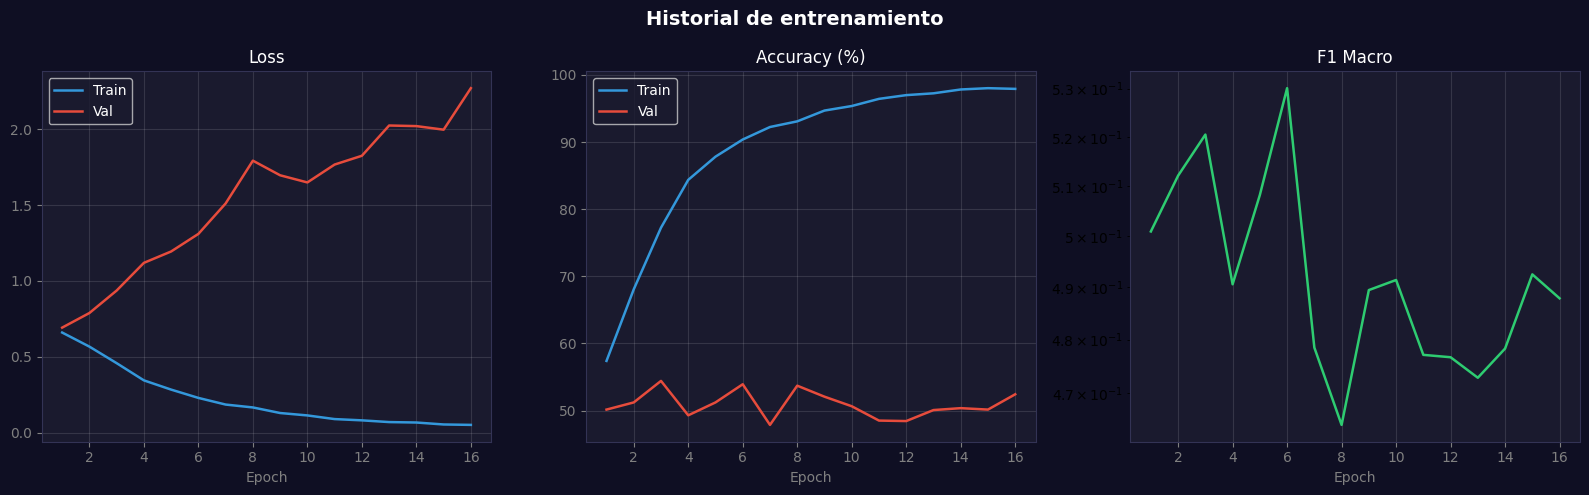


  TEST LOSS     : 1.2493
  TEST ACCURACY : 53.25%

              precision    recall  f1-score   support

         BUY      0.564     0.485     0.522       307
        SELL      0.506     0.585     0.543       277

    accuracy                          0.533       584
   macro avg      0.535     0.535     0.532       584
weighted avg      0.537     0.533     0.532       584



In [ ]:
# ── CELDA 19: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Historial de entrenamiento", color="white", fontsize=14, fontweight="bold")

ep = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#3498db", "val": "#e74c3c"}

# Loss
axes[0].plot(ep, history["train_loss"], color=colors["train"], label="Train", linewidth=1.8)
axes[0].plot(ep, history["val_loss"],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[0].set_title("Loss", color="white")
axes[0].set_xlabel("Epoch", color="gray")
axes[0].legend(facecolor="#1a1a2e", labelcolor="white")

# Accuracy
axes[1].plot(ep, [a * 100 for a in history["train_acc"]], color=colors["train"], label="Train", linewidth=1.8)
axes[1].plot(ep, [a * 100 for a in history["val_acc"]],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy (%)", color="white")
axes[1].set_xlabel("Epoch", color="gray")
axes[1].legend(facecolor="#1a1a2e", labelcolor="white")

# Learning rate
axes[2].semilogy(ep, history["val_f1"], color="#2ecc71", linewidth=1.8)
axes[2].set_title("F1 Macro", color="white")
axes[2].set_xlabel("Epoch", color="gray")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#333355")
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

# ── CELDA 20: Evaluación en Test Set ─────────────────────────────────────────
test_loss, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
probs  = np.array(probs)
preds  = np.array(preds)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"  TEST LOSS     : {test_loss:.4f}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

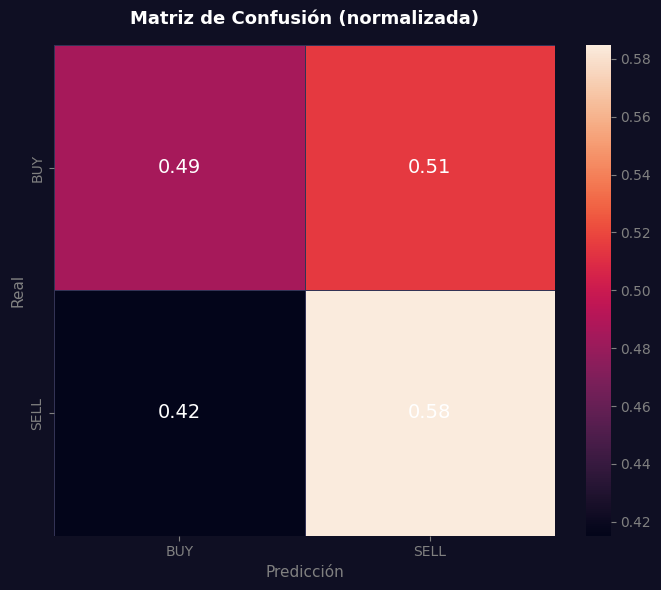

In [ ]:
# ── CELDA 21: Matriz de confusión ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="#333355",
    annot_kws={"size": 14, "color": "white"}
)
ax.set_title("Matriz de Confusión (normalizada)", color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicción", color="gray", fontsize=11)
ax.set_ylabel("Real", color="gray", fontsize=11)
ax.tick_params(colors="gray")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="gray")

plt.tight_layout()
plt.show()

In [ ]:
#
cm

array([[0.48534202, 0.51465798],
       [0.41516245, 0.58483755]])

## CNN custom

In [ ]:
# ── CELDA 15: Arquitectura CNN ────────────────────────────────────────────────
# Dos opciones. Elegí una descomentando el bloque correspondiente.

# ─── OPCIÓN A: CNN Custom liviana (ideal si el dataset es pequeño < 5000 imgs)

class SpectrogramCNN(nn.Module):
    """
    CNN de 4 bloques convolucionales diseñada para espectrogramas 64×64.
    Cada bloque: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
    """
    def __init__(self, num_classes=3, dropout=0.3):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True, drop=0.2):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            layers.append(nn.Dropout2d(drop))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   32,  pool=True,  drop=0.1),   # → 32×32
            conv_block(32,  64,  pool=True,  drop=0.15),  # → 16×16
            conv_block(64,  128, pool=True,  drop=0.2),   # → 8×8
            conv_block(128, 256, pool=True,  drop=0.25),  # → 4×4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),    # → 256×2×2 = 1024
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# ── Instanciar modelo ────────────────────────────────────────────────────────
model = SpectrogramCNN(num_classes=len(CLASSES)).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n🔢 Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {trainable_params:,}")

# ── CELDA 16: Loss, optimizador, schedulers ───────────────────────────────────

# class_counts del dataset completo: {0: 1466 (BUY), 1: 832 (SELL), 2: 3740 (HOLD)}
total = sum(class_counts.values())
weights = torch.tensor([
    total / class_counts[0],  # BUY
    total / class_counts[1],  # SELL
#    total / class_counts[2],  # HOLD
], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Reduce LR cuando val_loss no mejora
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

# Warmup + cosine decay (opcional, descomenta si usás ResNet)
# scheduler_cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

print("✅ Optimizador y scheduler configurados")
print(f"   LR inicial: {LR}  |  Weight decay: 1e-4  |  Label smoothing: 0.0")

# ── CELDA 17: Funciones de entrenamiento y evaluación ────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Evita exploding gradients
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


SpectrogramCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpl

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# ── CELDA 18: Loop de entrenamiento ──────────────────────────────────────────

from sklearn.metrics import f1_score

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_f1 = -1.0
best_weights = None
patience_ctr = 0

print(
    f"{'Epoch':>6} | "
    f"{'Train Loss':>10} | "
    f"{'Train Acc':>9} | "
    f"{'Val Loss':>8} | "
    f"{'Val Acc':>7} | "
    f"{'F1 Macro':>8} | "
    f"{'LR':>10}"
)

print("─" * 90)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    vl_loss, vl_acc, preds, labels, _ = eval_epoch(
        model,
        val_loader,
        criterion
    )

    val_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    scheduler_plateau.step(vl_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    # Checkpoint basado en F1 Macro
    if val_f1 > best_f1:

        best_f1 = val_f1

        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        patience_ctr = 0

        flag = f" ◀ best F1={val_f1:.4f}"

    else:

        patience_ctr += 1

        flag = (
            f" (no mejora {patience_ctr}/{EARLY_STOP})"
        )

    print(
        f"{epoch:>6} | "
        f"{tr_loss:>10.4f} | "
        f"{tr_acc*100:>8.2f}% | "
        f"{vl_loss:>8.4f} | "
        f"{vl_acc*100:>6.2f}% | "
        f"{val_f1:>8.4f} | "
        f"{current_lr:>10.2e}"
        f"{flag}"
    )

    if patience_ctr >= EARLY_STOP:
        print(f"\n⏹ Early stopping en epoch {epoch}")
        break

# Restaurar mejor modelo
if best_weights is not None:
    model.load_state_dict(best_weights)

torch.save(
    model.state_dict(),
    "cnn_best.pth"
)

print(
    f"\n✅ Mejor modelo guardado"
    f" | Val F1 Macro: {best_f1:.4f}"
)

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | F1 Macro |         LR
──────────────────────────────────────────────────────────────────────────────────────────
     1 |     0.6825 |    49.94% |   0.7088 |  40.53% |   0.2884 |   3.00e-04 ◀ best F1=0.2884
     2 |     0.6793 |    49.89% |   0.7073 |  40.53% |   0.2884 |   3.00e-04 (no mejora 1/10)
     3 |     0.6711 |    51.94% |   0.7377 |  40.53% |   0.2884 |   3.00e-04 (no mejora 2/10)
     4 |     0.6662 |    53.41% |   0.7430 |  41.60% |   0.3214 |   3.00e-04 ◀ best F1=0.3214
     5 |     0.6496 |    57.32% |   0.7352 |  49.64% |   0.4924 |   3.00e-04 ◀ best F1=0.4924
     6 |     0.6098 |    63.07% |   0.7694 |  52.85% |   0.5279 |   3.00e-04 ◀ best F1=0.5279
     7 |     0.5596 |    69.64% |   0.8778 |  48.01% |   0.4754 |   3.00e-04 (no mejora 1/10)
     8 |     0.4773 |    76.19% |   0.9150 |  49.93% |   0.4990 |   3.00e-04 (no mejora 2/10)
     9 |     0.4039 |    81.74% |   1.0570 |  51.99% |   0.5163 |   3.00e-04 (no

In [ ]:
%matplotlib inline

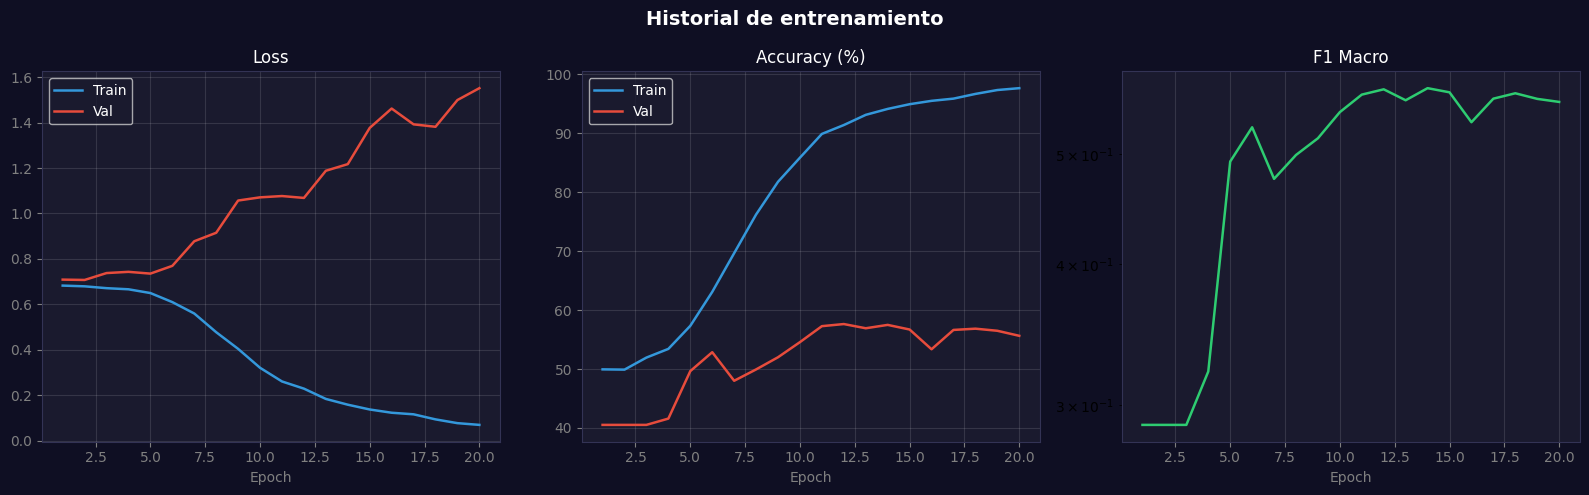


  TEST LOSS     : 1.0711
  TEST ACCURACY : 61.30%

              precision    recall  f1-score   support

         BUY      0.639     0.606     0.622       307
        SELL      0.587     0.621     0.604       277

    accuracy                          0.613       584
   macro avg      0.613     0.613     0.613       584
weighted avg      0.614     0.613     0.613       584



In [ ]:
# ── CELDA 19: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Historial de entrenamiento", color="white", fontsize=14, fontweight="bold")

ep = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#3498db", "val": "#e74c3c"}

# Loss
axes[0].plot(ep, history["train_loss"], color=colors["train"], label="Train", linewidth=1.8)
axes[0].plot(ep, history["val_loss"],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[0].set_title("Loss", color="white")
axes[0].set_xlabel("Epoch", color="gray")
axes[0].legend(facecolor="#1a1a2e", labelcolor="white")

# Accuracy
axes[1].plot(ep, [a * 100 for a in history["train_acc"]], color=colors["train"], label="Train", linewidth=1.8)
axes[1].plot(ep, [a * 100 for a in history["val_acc"]],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy (%)", color="white")
axes[1].set_xlabel("Epoch", color="gray")
axes[1].legend(facecolor="#1a1a2e", labelcolor="white")

# Learning rate
axes[2].semilogy(ep, history["val_f1"], color="#2ecc71", linewidth=1.8)
axes[2].set_title("F1 Macro", color="white")
axes[2].set_xlabel("Epoch", color="gray")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#333355")
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

# ── CELDA 20: Evaluación en Test Set ─────────────────────────────────────────
test_loss, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
probs  = np.array(probs)
preds  = np.array(preds)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"  TEST LOSS     : {test_loss:.4f}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

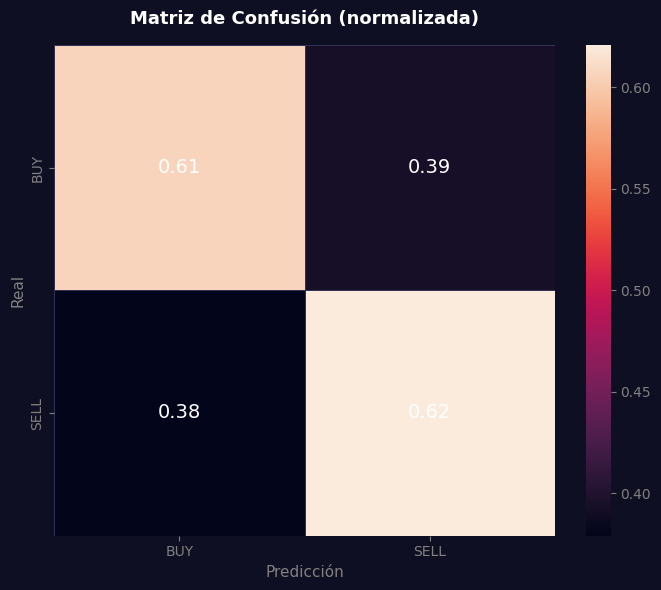

In [ ]:
# ── CELDA 21: Matriz de confusión ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="#333355",
    annot_kws={"size": 14, "color": "white"}
)
ax.set_title("Matriz de Confusión (normalizada)", color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicción", color="gray", fontsize=11)
ax.set_ylabel("Real", color="gray", fontsize=11)
ax.tick_params(colors="gray")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="gray")

plt.tight_layout()
plt.show()

In [ ]:
#
cm

array([[0.60586319, 0.39413681],
       [0.37906137, 0.62093863]])

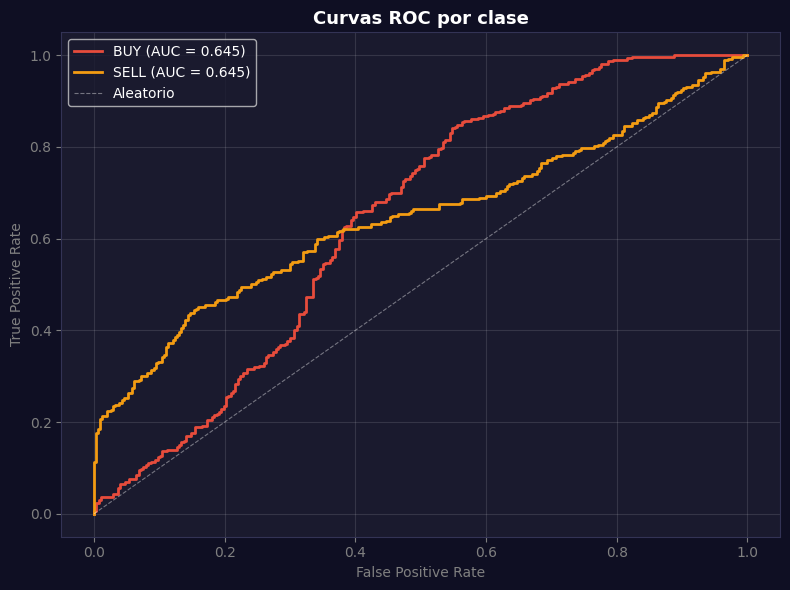

In [ ]:
# ── CELDA 22: Curvas ROC por clase ────────────────────────────────────────────
labels_bin = label_binarize(labels, classes=[0, 1, 2])
palette    = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

for i, (cls, color) in enumerate(zip(CLASSES, palette)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "w--", linewidth=0.8, alpha=0.4, label="Aleatorio")
ax.set_xlabel("False Positive Rate", color="gray")
ax.set_ylabel("True Positive Rate", color="gray")
ax.set_title("Curvas ROC por clase", color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.tick_params(colors="gray")
ax.spines[:].set_color("#333355")
ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

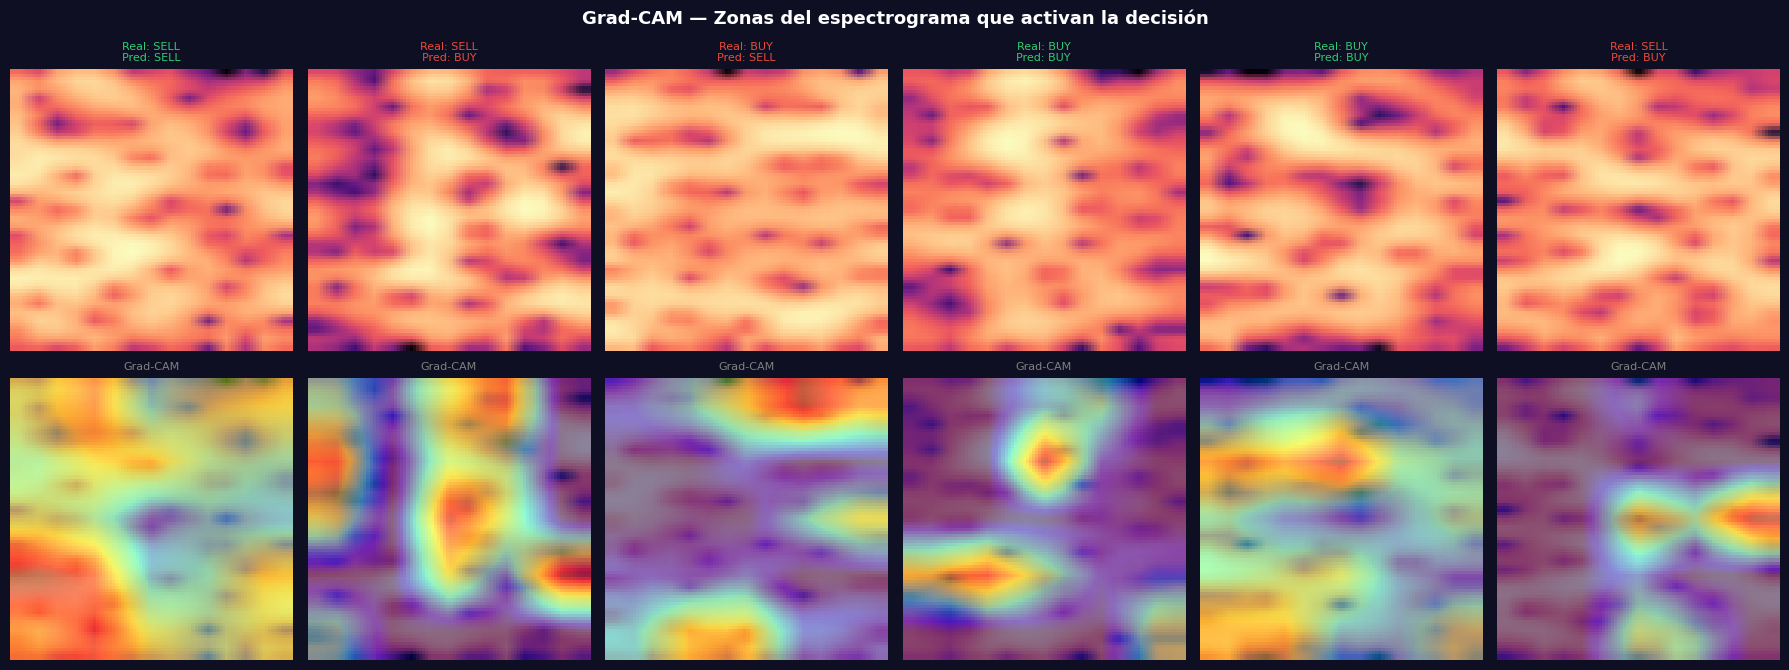

In [ ]:
# ── CELDA 23: Grad-CAM — ¿Qué parte del espectrograma mira la red? ────────────
# Implementación manual de Grad-CAM para la última capa convolucional

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx):
        self.model.eval()
        output = self.model(img_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()


# Acceder a la última capa conv del modelo custom
target_layer = list(model.features[-1].children())[-2]  # Último Conv2d
grad_cam     = GradCAM(model, target_layer)

# Tomar 6 ejemplos del test set
sample_imgs, sample_labels = next(iter(DataLoader(test_ds, batch_size=6, shuffle=True)))
sample_imgs  = sample_imgs.to(DEVICE)
sample_preds = model(sample_imgs).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Grad-CAM — Zonas del espectrograma que activan la decisión", color="white", fontsize=13, fontweight="bold")

unnorm = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])

for col in range(6):
    img_t  = sample_imgs[col:col+1]
    pred   = sample_preds[col].item()
    true   = sample_labels[col].item()
    cam    = grad_cam.generate(img_t, pred)

    # Imagen original
    img_show = unnorm(sample_imgs[col]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, col].imshow(img_show)
    axes[0, col].axis("off")
    color = "#2ecc71" if pred == true else "#e74c3c"
    axes[0, col].set_title(f"Real: {CLASSES[true]}\nPred: {CLASSES[pred]}", color=color, fontsize=8)

    # Grad-CAM superpuesto
    import cv2
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap     = plt.cm.jet(cam_resized)[:, :, :3]
    overlay     = 0.55 * img_show + 0.45 * heatmap
    axes[1, col].imshow(np.clip(overlay, 0, 1))
    axes[1, col].axis("off")
    axes[1, col].set_title("Grad-CAM", color="gray", fontsize=8)

for ax in axes.flat:
    ax.set_facecolor("#1a1a2e")

plt.tight_layout()
plt.show()

## EfficientNet

In [ ]:
# ── CELDA 15: Arquitectura CNN ────────────────────────────────────────────────
# Dos opciones. Elegí una descomentando el bloque correspondiente.

# ─── OPCIÓN C: EfficientNet
class EfficientNetFinancial(nn.Module):
    def __init__(self, num_classes=3, freeze_backbone=True):
        super().__init__()
        base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if freeze_backbone:
            for param in base.features.parameters():
                param.requires_grad = False
        in_features = base.classifier[1].in_features  # 1280
        base.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
        self.model = base

    def forward(self, x):
        return self.model(x)


# ── Instanciar modelo ────────────────────────────────────────────────────────
model = EfficientNetFinancial(num_classes=len(CLASSES)).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n🔢 Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {trainable_params:,}")

# ── CELDA 16: Loss, optimizador, schedulers ───────────────────────────────────

# class_counts del dataset completo: {0: 1466 (BUY), 1: 832 (SELL), 2: 3740 (HOLD)}
total = sum(class_counts.values())
weights = torch.tensor([
    total / class_counts[0],  # BUY
    total / class_counts[1],  # SELL
#    total / class_counts[2],  # HOLD
], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Reduce LR cuando val_loss no mejora
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

# Warmup + cosine decay (opcional, descomenta si usás ResNet)
# scheduler_cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

print("✅ Optimizador y scheduler configurados")
print(f"   LR inicial: {LR}  |  Weight decay: 1e-4  |  Label smoothing: 0.0")

# ── CELDA 17: Funciones de entrenamiento y evaluación ────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Evita exploding gradients
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s]


EfficientNetFinancial(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# ── CELDA 18: Loop de entrenamiento ──────────────────────────────────────────

from sklearn.metrics import f1_score

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_f1 = -1.0
best_weights = None
patience_ctr = 0

print(
    f"{'Epoch':>6} | "
    f"{'Train Loss':>10} | "
    f"{'Train Acc':>9} | "
    f"{'Val Loss':>8} | "
    f"{'Val Acc':>7} | "
    f"{'F1 Macro':>8} | "
    f"{'LR':>10}"
)

print("─" * 90)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    vl_loss, vl_acc, preds, labels, _ = eval_epoch(
        model,
        val_loader,
        criterion
    )

    val_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    scheduler_plateau.step(vl_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    # Checkpoint basado en F1 Macro
    if val_f1 > best_f1:

        best_f1 = val_f1

        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        patience_ctr = 0

        flag = f" ◀ best F1={val_f1:.4f}"

    else:

        patience_ctr += 1

        flag = (
            f" (no mejora {patience_ctr}/{EARLY_STOP})"
        )

    print(
        f"{epoch:>6} | "
        f"{tr_loss:>10.4f} | "
        f"{tr_acc*100:>8.2f}% | "
        f"{vl_loss:>8.4f} | "
        f"{vl_acc*100:>6.2f}% | "
        f"{val_f1:>8.4f} | "
        f"{current_lr:>10.2e}"
        f"{flag}"
    )

    if patience_ctr >= EARLY_STOP:
        print(f"\n⏹ Early stopping en epoch {epoch}")
        break

# Restaurar mejor modelo
if best_weights is not None:
    model.load_state_dict(best_weights)

torch.save(
    model.state_dict(),
    "spectrogram_cnn_best.pth"
)

print(
    f"\n✅ Mejor modelo guardado"
    f" | Val F1 Macro: {best_f1:.4f}"
)

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | F1 Macro |         LR
──────────────────────────────────────────────────────────────────────────────────────────
     1 |     0.6816 |    50.69% |   0.7082 |  40.67% |   0.2949 |   3.00e-04 ◀ best F1=0.2949
     2 |     0.6740 |    51.85% |   0.7063 |  43.23% |   0.4006 |   3.00e-04 ◀ best F1=0.4006
     3 |     0.6663 |    53.43% |   0.7069 |  46.15% |   0.4550 |   3.00e-04 ◀ best F1=0.4550
     4 |     0.6660 |    54.46% |   0.7091 |  46.58% |   0.4626 |   3.00e-04 ◀ best F1=0.4626
     5 |     0.6671 |    54.01% |   0.7108 |  45.51% |   0.4500 |   3.00e-04 (no mejora 1/10)
     6 |     0.6643 |    54.33% |   0.7135 |  45.09% |   0.4454 |   3.00e-04 (no mejora 2/10)
     7 |     0.6664 |    55.34% |   0.7101 |  48.29% |   0.4829 |   3.00e-04 ◀ best F1=0.4829
     8 |     0.6617 |    56.37% |   0.7183 |  45.66% |   0.4491 |   3.00e-04 (no mejora 1/10)
     9 |     0.6608 |    56.12% |   0.7214 |  45.16% |   0.4400 |   3.00e-04 (no

In [ ]:
%matplotlib inline

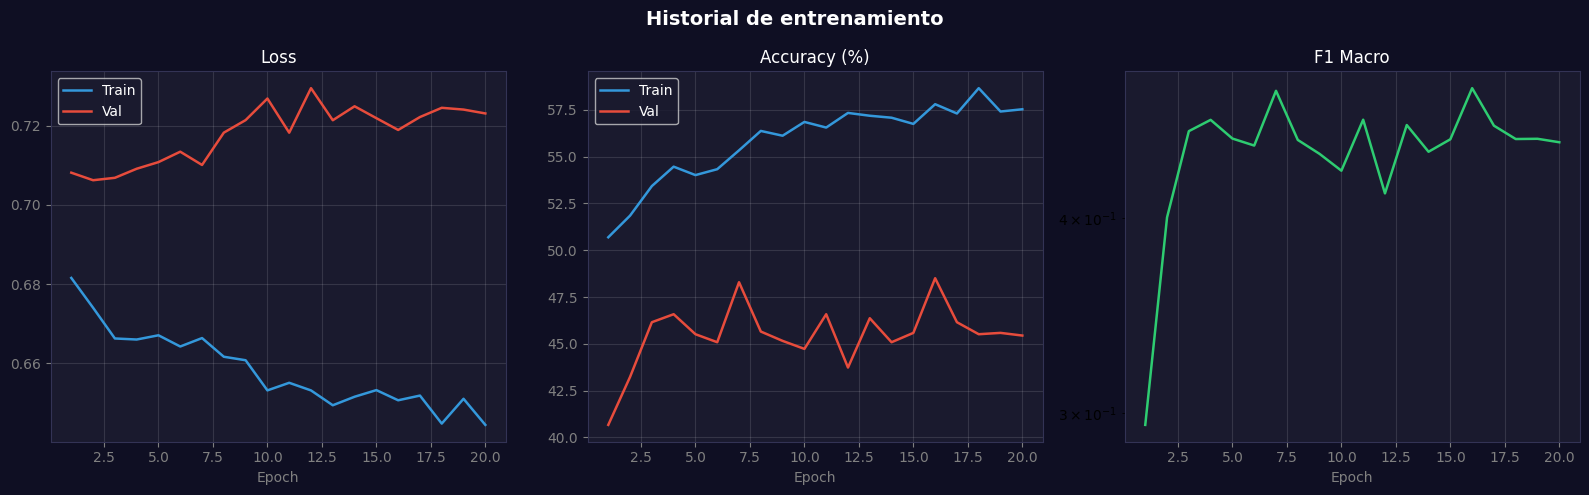


  TEST LOSS     : 0.6998
  TEST ACCURACY : 50.34%

              precision    recall  f1-score   support

         BUY      0.557     0.270     0.364       307
        SELL      0.485     0.762     0.593       277

    accuracy                          0.503       584
   macro avg      0.521     0.516     0.478       584
weighted avg      0.523     0.503     0.472       584



In [ ]:
# ── CELDA 19: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Historial de entrenamiento", color="white", fontsize=14, fontweight="bold")

ep = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#3498db", "val": "#e74c3c"}

# Loss
axes[0].plot(ep, history["train_loss"], color=colors["train"], label="Train", linewidth=1.8)
axes[0].plot(ep, history["val_loss"],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[0].set_title("Loss", color="white")
axes[0].set_xlabel("Epoch", color="gray")
axes[0].legend(facecolor="#1a1a2e", labelcolor="white")

# Accuracy
axes[1].plot(ep, [a * 100 for a in history["train_acc"]], color=colors["train"], label="Train", linewidth=1.8)
axes[1].plot(ep, [a * 100 for a in history["val_acc"]],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy (%)", color="white")
axes[1].set_xlabel("Epoch", color="gray")
axes[1].legend(facecolor="#1a1a2e", labelcolor="white")

# Learning rate
axes[2].semilogy(ep, history["val_f1"], color="#2ecc71", linewidth=1.8)
axes[2].set_title("F1 Macro", color="white")
axes[2].set_xlabel("Epoch", color="gray")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#333355")
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

# ── CELDA 20: Evaluación en Test Set ─────────────────────────────────────────
test_loss, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
probs  = np.array(probs)
preds  = np.array(preds)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"  TEST LOSS     : {test_loss:.4f}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

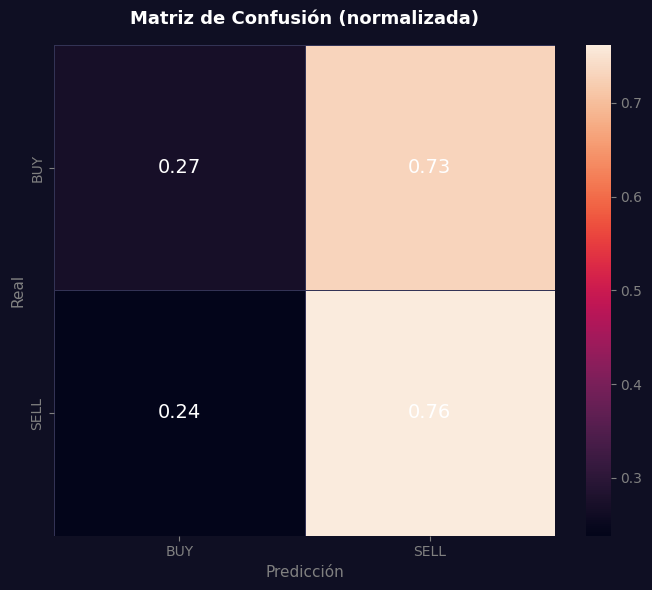

In [ ]:
# ── CELDA 21: Matriz de confusión ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="#333355",
    annot_kws={"size": 14, "color": "white"}
)
ax.set_title("Matriz de Confusión (normalizada)", color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicción", color="gray", fontsize=11)
ax.set_ylabel("Real", color="gray", fontsize=11)
ax.tick_params(colors="gray")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="gray")

plt.tight_layout()
plt.show()

In [ ]:
#
cm

array([[0.27035831, 0.72964169],
       [0.23826715, 0.76173285]])

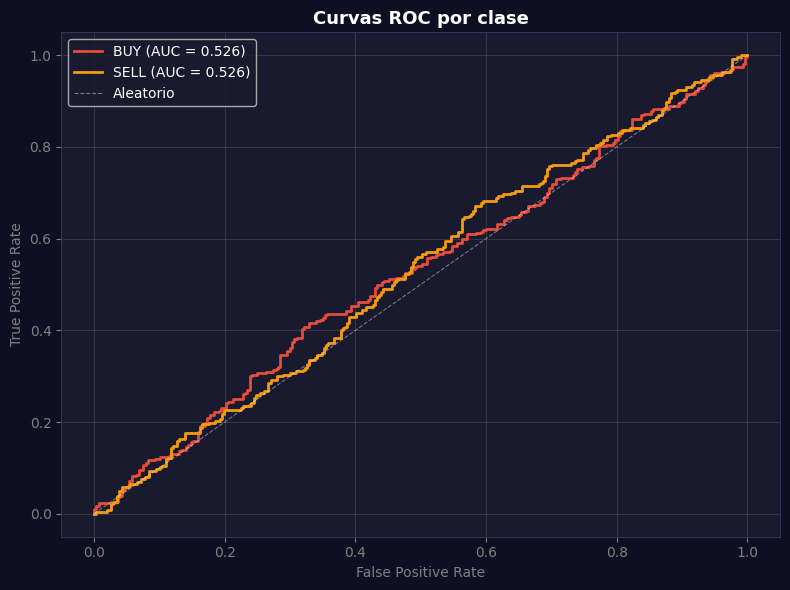

In [ ]:
# ── CELDA 22: Curvas ROC por clase ────────────────────────────────────────────
labels_bin = label_binarize(labels, classes=[0, 1, 2])
palette    = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

for i, (cls, color) in enumerate(zip(CLASSES, palette)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "w--", linewidth=0.8, alpha=0.4, label="Aleatorio")
ax.set_xlabel("False Positive Rate", color="gray")
ax.set_ylabel("True Positive Rate", color="gray")
ax.set_title("Curvas ROC por clase", color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.tick_params(colors="gray")
ax.spines[:].set_color("#333355")
ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

## CNN v2

In [ ]:
# ── CELDA 15: Arquitectura CNN ────────────────────────────────────────────────
# Dos opciones. Elegí una descomentando el bloque correspondiente.

# ─── OPCIÓN A: CNN Custom liviana (ideal si el dataset es pequeño < 5000 imgs)

class SpectrogramCNNv2(nn.Module):
    """
    Variante de SpectrogramCNN con:
      - Global Average Pooling en vez de AdaptiveAvgPool(2,2)+Flatten
        → reduce drásticamente los parámetros del clasificador
          (256 vs 1024 → menos overfitting en la cabeza)
      - Stochastic Depth / Dropout2d más agresivo en capas profundas
      - Activación GELU en vez de ReLU (suele ayudar con datasets chicos)
    """
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=True, drop=0.2):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            layers.append(nn.Dropout2d(drop))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(3,   32,  pool=True,  drop=0.1),   # → 46×46
            conv_block(32,  64,  pool=True,  drop=0.15),  # → 23×23
            conv_block(64,  128, pool=True,  drop=0.2),   # → 11×11
            conv_block(128, 256, pool=True,  drop=0.25),  # → 5×5
        )

        # Global Average Pooling: 256×H×W → 256 (sin importar H,W)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),                 # → 256
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)

# ── Instanciar modelo ────────────────────────────────────────────────────────
model = SpectrogramCNNv2(num_classes=len(CLASSES)).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\n🔢 Parámetros totales     : {total_params:,}")
print(f"   Parámetros entrenables : {trainable_params:,}")

# ── CELDA 16: Loss, optimizador, schedulers ───────────────────────────────────

# class_counts del dataset completo: {0: 1466 (BUY), 1: 832 (SELL), 2: 3740 (HOLD)}
total = sum(class_counts.values())
weights = torch.tensor([
    total / class_counts[0],  # BUY
    total / class_counts[1],  # SELL
#    total / class_counts[2],  # HOLD
], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Reduce LR cuando val_loss no mejora
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=LR_PATIENCE
)

# Warmup + cosine decay (opcional, descomenta si usás ResNet)
# scheduler_cosine = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

print("✅ Optimizador y scheduler configurados")
print(f"   LR inicial: {LR}  |  Weight decay: 1e-4  |  Label smoothing: 0.0")

# ── CELDA 17: Funciones de entrenamiento y evaluación ────────────────────────
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Evita exploding gradients
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs


SpectrogramCNNv2(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout2d(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# ── CELDA 18: Loop de entrenamiento ──────────────────────────────────────────

from sklearn.metrics import f1_score

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}

best_f1 = -1.0
best_weights = None
patience_ctr = 0

print(
    f"{'Epoch':>6} | "
    f"{'Train Loss':>10} | "
    f"{'Train Acc':>9} | "
    f"{'Val Loss':>8} | "
    f"{'Val Acc':>7} | "
    f"{'F1 Macro':>8} | "
    f"{'LR':>10}"
)

print("─" * 90)

for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    vl_loss, vl_acc, preds, labels, _ = eval_epoch(
        model,
        val_loader,
        criterion
    )

    val_f1 = f1_score(
        labels,
        preds,
        average="macro"
    )

    scheduler_plateau.step(vl_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    # Checkpoint basado en F1 Macro
    if val_f1 > best_f1:

        best_f1 = val_f1

        best_weights = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }

        patience_ctr = 0

        flag = f" ◀ best F1={val_f1:.4f}"

    else:

        patience_ctr += 1

        flag = (
            f" (no mejora {patience_ctr}/{EARLY_STOP})"
        )

    print(
        f"{epoch:>6} | "
        f"{tr_loss:>10.4f} | "
        f"{tr_acc*100:>8.2f}% | "
        f"{vl_loss:>8.4f} | "
        f"{vl_acc*100:>6.2f}% | "
        f"{val_f1:>8.4f} | "
        f"{current_lr:>10.2e}"
        f"{flag}"
    )

    if patience_ctr >= EARLY_STOP:
        print(f"\n⏹ Early stopping en epoch {epoch}")
        break

# Restaurar mejor modelo
if best_weights is not None:
    model.load_state_dict(best_weights)

torch.save(
    model.state_dict(),
    "cnn_best_v2.pth"
)

print(
    f"\n✅ Mejor modelo guardado"
    f" | Val F1 Macro: {best_f1:.4f}"
)

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | F1 Macro |         LR
──────────────────────────────────────────────────────────────────────────────────────────
     1 |     0.6858 |    50.44% |   0.7069 |  40.53% |   0.2884 |   3.00e-04 ◀ best F1=0.2884
     2 |     0.6808 |    50.59% |   0.7160 |  40.53% |   0.2884 |   3.00e-04 (no mejora 1/10)
     3 |     0.6790 |    50.27% |   0.7240 |  40.53% |   0.2884 |   3.00e-04 (no mejora 2/10)
     4 |     0.6774 |    50.41% |   0.7180 |  40.53% |   0.2884 |   3.00e-04 (no mejora 3/10)
     5 |     0.6798 |    49.76% |   0.7298 |  40.74% |   0.2943 |   3.00e-04 ◀ best F1=0.2943
     6 |     0.6750 |    51.19% |   0.7165 |  40.53% |   0.2884 |   3.00e-04 (no mejora 1/10)
     7 |     0.6703 |    51.98% |   0.7256 |  40.88% |   0.2960 |   3.00e-04 ◀ best F1=0.2960
     8 |     0.6691 |    52.49% |   0.7055 |  41.17% |   0.3190 |   3.00e-04 ◀ best F1=0.3190
     9 |     0.6629 |    54.18% |   0.6911 |  51.35% |   0.5064 |   3.00e-04 ◀ b

In [ ]:
%matplotlib inline

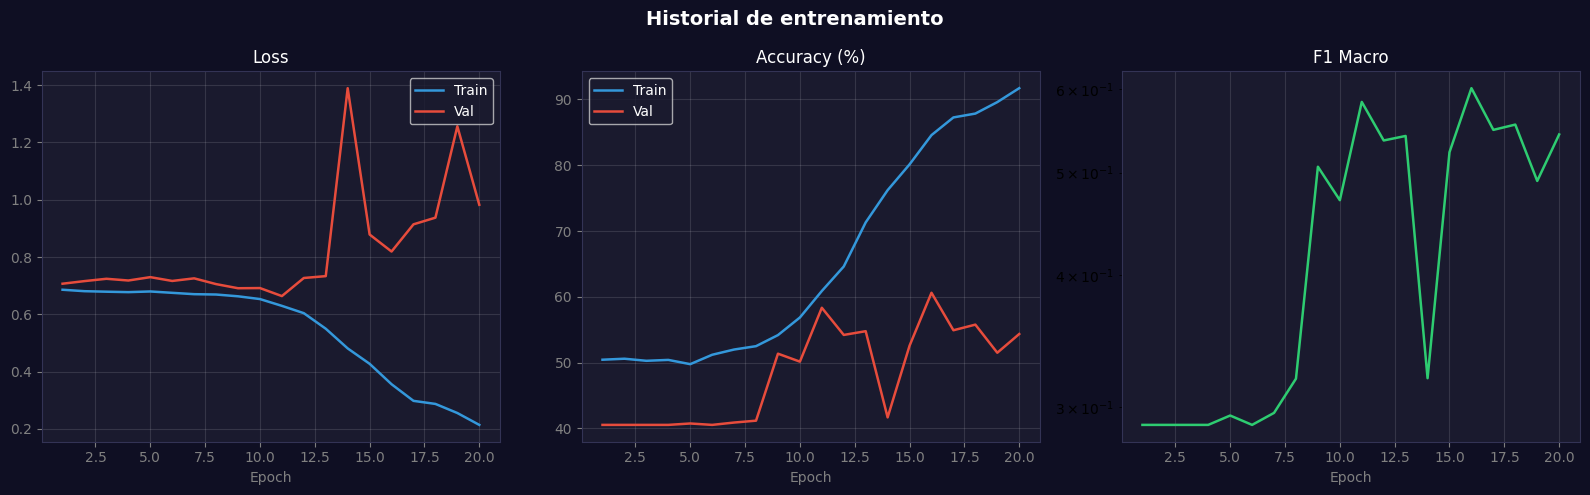


  TEST LOSS     : 0.9791
  TEST ACCURACY : 52.40%

              precision    recall  f1-score   support

         BUY      0.544     0.580     0.562       307
        SELL      0.498     0.462     0.479       277

    accuracy                          0.524       584
   macro avg      0.521     0.521     0.520       584
weighted avg      0.522     0.524     0.523       584



In [ ]:
# ── CELDA 19: Curvas de entrenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Historial de entrenamiento", color="white", fontsize=14, fontweight="bold")

ep = range(1, len(history["train_loss"]) + 1)
colors = {"train": "#3498db", "val": "#e74c3c"}

# Loss
axes[0].plot(ep, history["train_loss"], color=colors["train"], label="Train", linewidth=1.8)
axes[0].plot(ep, history["val_loss"],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[0].set_title("Loss", color="white")
axes[0].set_xlabel("Epoch", color="gray")
axes[0].legend(facecolor="#1a1a2e", labelcolor="white")

# Accuracy
axes[1].plot(ep, [a * 100 for a in history["train_acc"]], color=colors["train"], label="Train", linewidth=1.8)
axes[1].plot(ep, [a * 100 for a in history["val_acc"]],   color=colors["val"],   label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy (%)", color="white")
axes[1].set_xlabel("Epoch", color="gray")
axes[1].legend(facecolor="#1a1a2e", labelcolor="white")

# Learning rate
axes[2].semilogy(ep, history["val_f1"], color="#2ecc71", linewidth=1.8)
axes[2].set_title("F1 Macro", color="white")
axes[2].set_xlabel("Epoch", color="gray")

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#333355")
    ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

# ── CELDA 20: Evaluación en Test Set ─────────────────────────────────────────
test_loss, test_acc, preds, labels, probs = eval_epoch(model, test_loader, criterion)
probs  = np.array(probs)
preds  = np.array(preds)
labels = np.array(labels)

print(f"\n{'='*50}")
print(f"  TEST LOSS     : {test_loss:.4f}")
print(f"  TEST ACCURACY : {test_acc*100:.2f}%")
print(f"{'='*50}\n")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

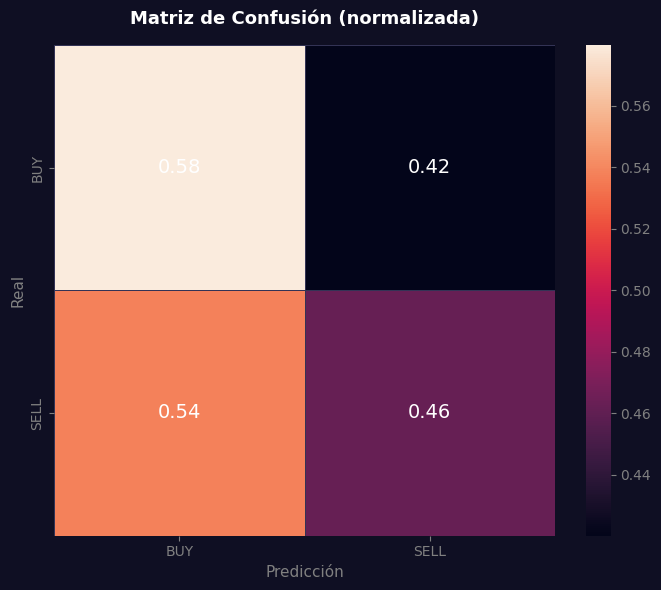

In [ ]:
# ── CELDA 21: Matriz de confusión ─────────────────────────────────────────────
cm = confusion_matrix(labels, preds, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

sns.heatmap(
    cm, annot=True, fmt=".2f",
    xticklabels=CLASSES, yticklabels=CLASSES,
    ax=ax, linewidths=0.5, linecolor="#333355",
    annot_kws={"size": 14, "color": "white"}
)
ax.set_title("Matriz de Confusión (normalizada)", color="white", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Predicción", color="gray", fontsize=11)
ax.set_ylabel("Real", color="gray", fontsize=11)
ax.tick_params(colors="gray")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="gray")

plt.tight_layout()
plt.show()

In [ ]:
#
cm

array([[0.57980456, 0.42019544],
       [0.53790614, 0.46209386]])

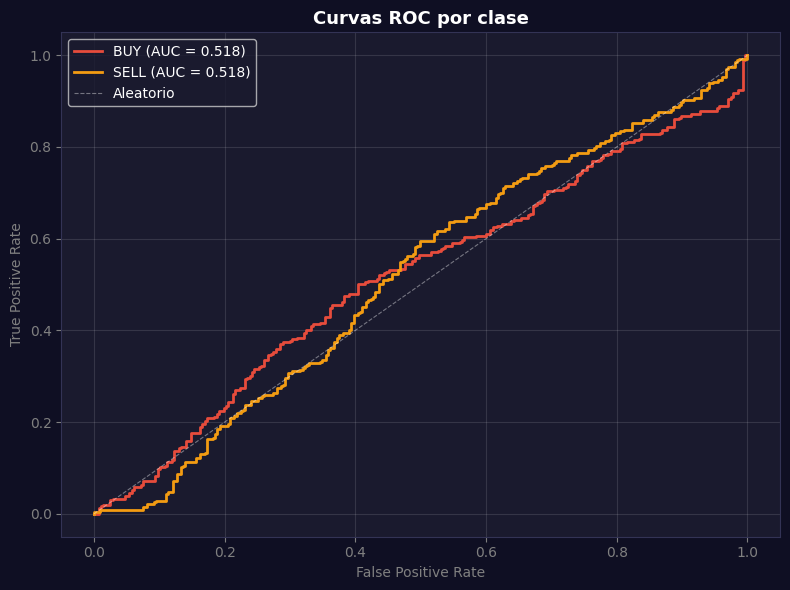

In [ ]:
# ── CELDA 22: Curvas ROC por clase ────────────────────────────────────────────
labels_bin = label_binarize(labels, classes=[0, 1, 2])
palette    = ["#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

for i, (cls, color) in enumerate(zip(CLASSES, palette)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "w--", linewidth=0.8, alpha=0.4, label="Aleatorio")
ax.set_xlabel("False Positive Rate", color="gray")
ax.set_ylabel("True Positive Rate", color="gray")
ax.set_title("Curvas ROC por clase", color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#1a1a2e", labelcolor="white")
ax.tick_params(colors="gray")
ax.spines[:].set_color("#333355")
ax.grid(True, alpha=0.12, color="white")

plt.tight_layout()
plt.show()

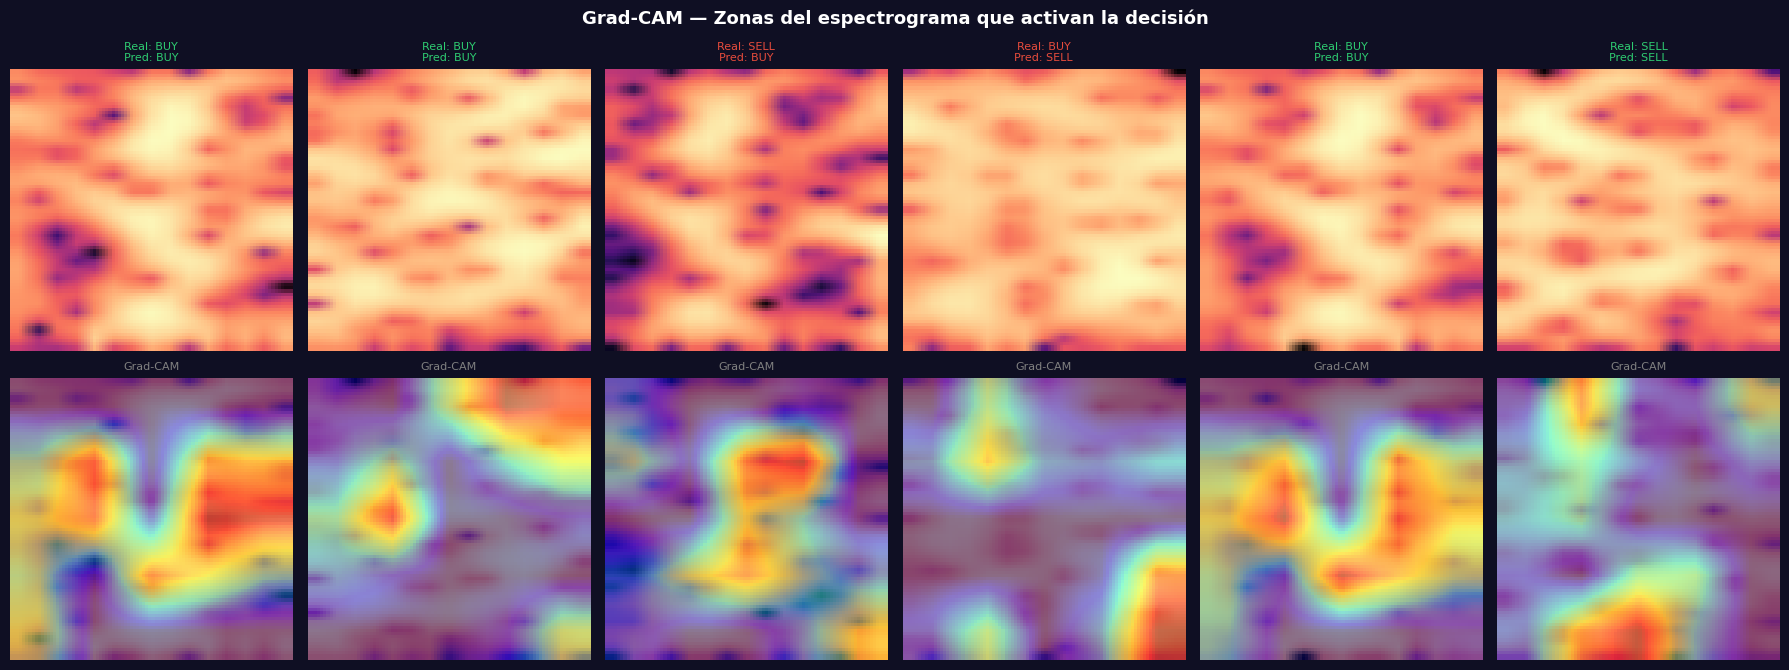

In [ ]:
# ── CELDA 23: Grad-CAM — ¿Qué parte del espectrograma mira la red? ────────────
# Implementación manual de Grad-CAM para la última capa convolucional

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx):
        self.model.eval()
        output = self.model(img_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.clamp(cam, min=0)
        cam     = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()


# Acceder a la última capa conv del modelo custom
target_layer = list(model.features[-1].children())[-2]  # Último Conv2d
grad_cam     = GradCAM(model, target_layer)

# Tomar 6 ejemplos del test set
sample_imgs, sample_labels = next(iter(DataLoader(test_ds, batch_size=6, shuffle=True)))
sample_imgs  = sample_imgs.to(DEVICE)
sample_preds = model(sample_imgs).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f23")
fig.suptitle("Grad-CAM — Zonas del espectrograma que activan la decisión", color="white", fontsize=13, fontweight="bold")

unnorm = transforms.Normalize(mean=[-1, -1, -1], std=[2, 2, 2])

for col in range(6):
    img_t  = sample_imgs[col:col+1]
    pred   = sample_preds[col].item()
    true   = sample_labels[col].item()
    cam    = grad_cam.generate(img_t, pred)

    # Imagen original
    img_show = unnorm(sample_imgs[col]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0, col].imshow(img_show)
    axes[0, col].axis("off")
    color = "#2ecc71" if pred == true else "#e74c3c"
    axes[0, col].set_title(f"Real: {CLASSES[true]}\nPred: {CLASSES[pred]}", color=color, fontsize=8)

    # Grad-CAM superpuesto
    import cv2
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap     = plt.cm.jet(cam_resized)[:, :, :3]
    overlay     = 0.55 * img_show + 0.45 * heatmap
    axes[1, col].imshow(np.clip(overlay, 0, 1))
    axes[1, col].axis("off")
    axes[1, col].set_title("Grad-CAM", color="gray", fontsize=8)

for ax in axes.flat:
    ax.set_facecolor("#1a1a2e")

plt.tight_layout()
plt.show()